<Figure size 1600x700 with 0 Axes>

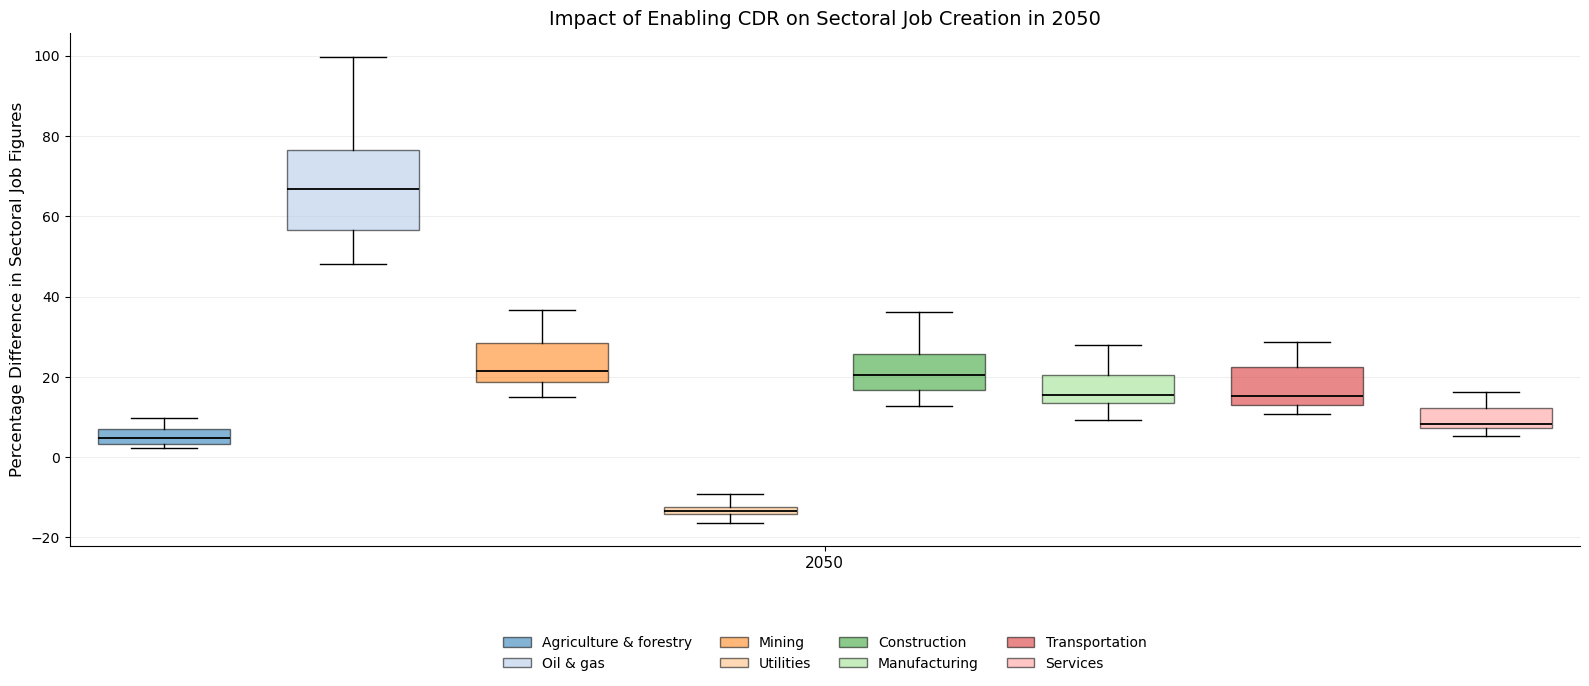

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- Axes/figure setup ----
plt.figure(figsize=(16, 7))
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

# ---- Categories ----
years = [2030, 2035, 2040, 2045, 2050]
sectors = [
    "Agriculture & forestry",
    "Oil & gas",
    "Mining",
    "Utilities",
    "Construction",
    "Manufacturing",
    "Transportation",
    "Services",
]
n_years = len(years)
n_sectors = len(sectors)

# ---- CONSTANTS (exact order: for each sector block of 5 years) ----
# Order across columns is:
# [Ag&For(2030..2050), Oil&Gas(2030..2050), Mining(2030..2050), Utilities(2030..2050),
#  Construction(2030..2050), Manufacturing(2030..2050), Transportation(2030..2050), Services(2030..2050)]
mins_ = [
    -0.066088542, -3.061791056, 0.041260402, -0.645245046, 2.39612241,
    -0.433527786, -0.288538956, 5.134964267, 14.8380372, 48.17374472,
    -0.021559519, -0.436485067, 1.270447707, 6.549817648, 14.97660804,
    -0.017153031, -0.484346258, -1.459977084, -4.487060215, -16.33665718,
    -0.048790657, -1.12158647, 2.430082048, 6.438569929, 12.80435233,
    -0.438708647, -2.10286713, 0.620511312, 3.393362334, 9.284229695,
    -0.012907998, -0.124136062, 1.351908598, 4.523859803, 10.64510235,
    -0.006000457, -0.698372116, 0.394876463, 1.723833505, 5.315114987
]
q1_ = [
    -0.003104072, 0.002139921, 0.53043298, 0.582141833, 3.411807315,
    -0.009126395, 0.047581825, 8.040711093, 23.38717315, 56.64460047,
    -0.001588486, 0.019714436, 2.510619215, 11.13702524, 18.8144221,
    -0.002721637, -0.189079252, -0.731670832, -3.312499992, -14.2069237,
    -0.007435262, 0.020958468, 3.739154754, 8.649438997, 16.66854875,
    -0.003807372, 0.054541873, 2.336674601, 6.47615978, 13.48745609,
    -0.001661925, 0.028731612, 2.601016927, 6.600461818, 12.97119519,
    -0.000391333, 0.007232114, 0.931732231, 2.966900611, 7.289539718
]
med_ = [
    -0.000155278, 0.069488927, 0.739176131, 1.266981622, 4.83145187,
    -0.0003214, 1.171340874, 10.5395483, 27.99011382, 66.9301238,
    1.78538e-05, 0.304129342, 3.693881871, 13.81544286, 21.59380338,
    0.000187332, -0.11002544, -0.544167754, -2.754437777, -13.42980867,
    0.000246316, 0.485490119, 5.380801314, 10.59584811, 20.47449422,
    0.00147144, 0.328168068, 3.148650423, 8.733947431, 15.45032732,
    0.000171699, 0.325473459, 3.832561428, 8.420243238, 15.25992283,
    0.000150496, 0.101989207, 1.368571659, 3.952753551, 8.261419841
]
q3_ = [
    0.002713314, 0.220654034, 1.054352037, 2.324592549, 6.904576258,
    0.007300779, 2.13267684, 14.90947845, 33.66840561, 76.44901299,
    0.002393957, 1.065536436, 5.092584496, 18.01790953, 28.40357946,
    0.001704201, -0.001990734, -0.22817249, -2.195303505, -12.47754142,
    0.005765841, 1.227093259, 6.807533079, 12.45059689, 25.70362566,
    0.005205697, 0.815836271, 4.199786396, 12.9814805, 20.56430168,
    0.002709612, 0.818021259, 4.66415293, 11.86003013, 22.48340781,
    0.00072727, 0.254750964, 1.832448567, 5.568653234, 12.222525
]
max_ = [
    0.063971734, 0.525158252, 1.867695933, 4.197588387, 9.650925775,
    0.181825279, 5.106932246, 23.13130891, 48.07535175, 99.83155024,
    0.026301762, 1.65477475, 8.906639519, 24.96587179, 36.79796933,
    0.05902265, 1.357776573, 0.221296981, -1.015393432, -9.248178112,
    0.090651594, 7.443328025, 11.32626721, 17.39274925, 36.1057461,
    0.451856686, 1.519158927, 7.297128981, 17.68916575, 27.86178209,
    0.020570426, 1.901119839, 8.149532146, 14.8961473, 28.62770785,
    0.0084851, 0.614508499, 3.545882357, 7.91704795, 16.25746827
]

# ---- Filter to keep only 2040, 2045, 2050 ----
base_years_full = [2030, 2035, 2040, 2045, 2050]   # original layout of the arrays
base_n_years = len(base_years_full)                # = 5

keep_years = [2050]
keep_indices = [i for i, y in enumerate(base_years_full) if y in keep_years]

def filter_years(arr, block_size, keep_idx):
    filtered = []
    for si in range(n_sectors):
        block = arr[si * block_size : (si + 1) * block_size]   # slice using ORIGINAL size (5)
        filtered.extend([block[i] for i in keep_idx])
    return filtered

# Apply filtering using the original block size
mins_ = filter_years(mins_, base_n_years, keep_indices)
q1_   = filter_years(q1_,   base_n_years, keep_indices)
med_  = filter_years(med_,  base_n_years, keep_indices)
q3_   = filter_years(q3_,   base_n_years, keep_indices)
max_  = filter_years(max_,  base_n_years, keep_indices)

# Now update years/n_years to the kept set
years = keep_years
n_years = len(years)

assert len(mins_) == len(q1_) == len(med_) == len(q3_) == len(max_) == n_sectors * n_years


# ---- Build bxp stats grouped by year & sector ----
# positions: each year is a group; within each group, 8 boxes (one per sector)
gap = 1.0                       # space between year-groups
width = 0.7                     # box width
stats_by_sector = {s: [] for s in sectors}
positions_by_sector = {s: [] for s in sectors}

idx = 0
for yi, year in enumerate(years):
    group_start = yi * (n_sectors + gap) + 1  # left x for the group
    for si, sector in enumerate(sectors):
        # Because the data are arranged by sector blocks, compute index properly
        # sector_block_offset = si * n_years + yi
        sector_block_offset = si * n_years + yi
        s = {
            "label": f"{sector} {year}",
            "whislo": mins_[sector_block_offset],
            "q1": q1_[sector_block_offset],
            "med": med_[sector_block_offset],
            "q3": q3_[sector_block_offset],
            "whishi": max_[sector_block_offset],
        }
        stats_by_sector[sector].append(s)
        positions_by_sector[sector].append(group_start + si)

fig, ax = plt.subplots(figsize=(16, 7))
colors = plt.cm.tab20.colors  # 20 distinct colors
handles = []

for si, sector in enumerate(sectors):
    col = colors[si % len(colors)]
    bp = ax.bxp(
        stats_by_sector[sector],
        positions=positions_by_sector[sector],
        widths=width,
        showfliers=False,
        patch_artist=True,
        boxprops={"facecolor": col, "alpha": 0.55, "edgecolor": "black"},
        medianprops={"color": "black", "linewidth": 1.3},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
    )
    handles.append(Patch(facecolor=col, edgecolor="black", label=sector, alpha=0.55))

# ---- X ticks centered under each year group ----
centers = [yi * (n_sectors + gap) + 1 + (n_sectors - 1) / 2 for yi in range(n_years)]
ax.set_xticks(centers)
ax.set_xticklabels([str(y) for y in years], fontsize=11)

# ---- Labels, grid, legend ----
ax.set_ylabel("Percentage Difference in Sectoral Job Figures", fontsize=12)
ax.set_title("Impact of Enabling CDR on Sectoral Job Creation in 2050", fontsize=14)
ax.grid(axis="y", alpha=0.2)
ax.legend(
    handles=handles,
    ncol=4,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15)  # x=0.5 centers horizontally, y is below x-axis
)


plt.tight_layout()
plt.show()


<Figure size 1600x700 with 0 Axes>

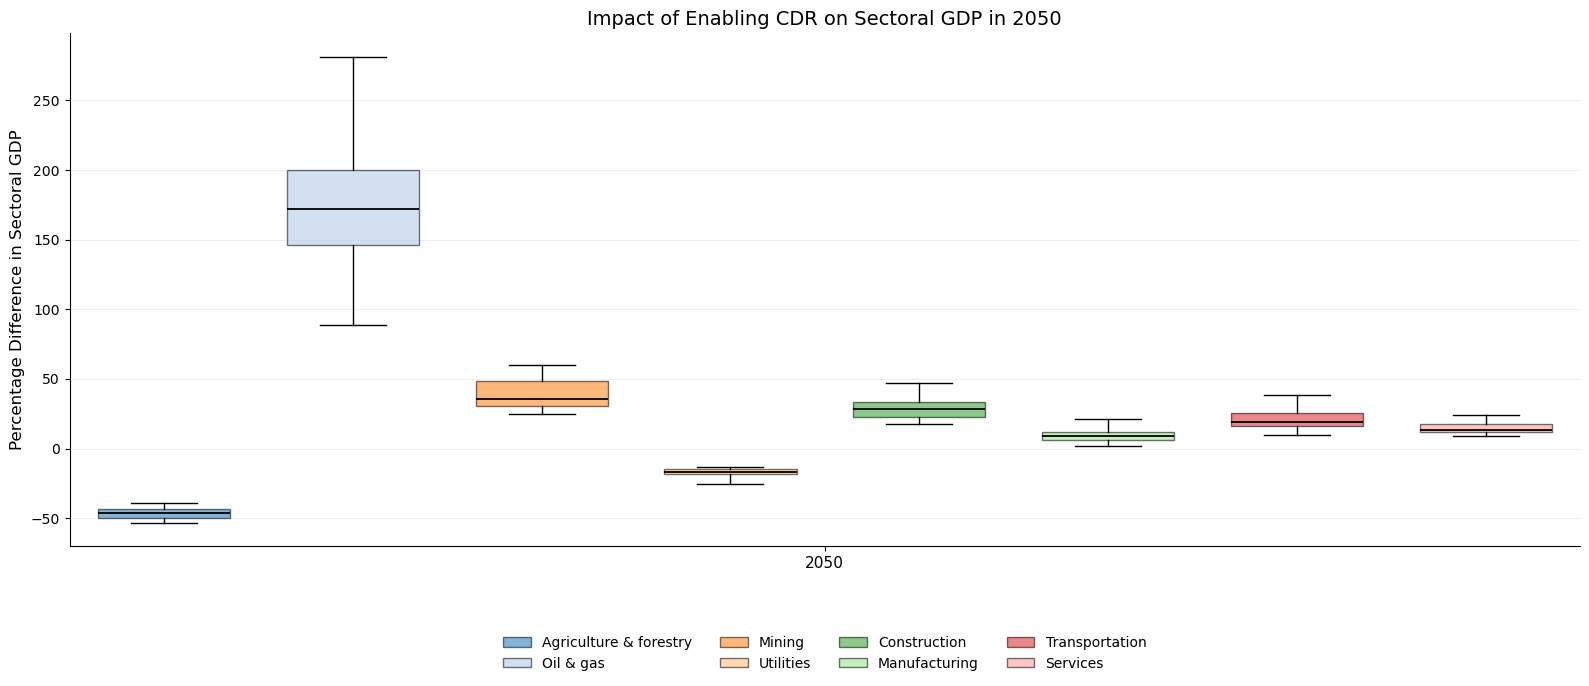

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- Axes/figure setup ----
plt.figure(figsize=(16, 7))
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

# ---- Categories ----
years = [2030, 2035, 2040, 2045, 2050]
sectors = [
    "Agriculture & forestry",
    "Oil & gas",
    "Mining",
    "Utilities",
    "Construction",
    "Manufacturing",
    "Transportation",
    "Services",
]
n_years = len(years)
n_sectors = len(sectors)

# ---- CONSTANTS (exact order: for each sector block of 5 years) ----
# Order across columns is:
# [Ag&For(2030..2050), Oil&Gas(2030..2050), Mining(2030..2050), Utilities(2030..2050),
#  Construction(2030..2050), Manufacturing(2030..2050), Transportation(2030..2050), Services(2030..2050)]
mins_ = [
    -0.070154787, -2.260031773, -9.577584152, -23.59516611, -53.28451713,
    -0.117723137, -0.968162984, 3.642571542, 23.87281749, 89.04864686,
    -0.052307671, -6.770249149, 0.616718419, 10.95154896, 24.96868821,
    -0.172031439, -8.165442339, -4.107200646, -13.6732831, -25.37146843,
    -0.062358146, -0.81891347, 3.102441337, 8.268033947, 17.56827895,
    -0.12211176, -2.657654438, 0.071847813, -4.094810778, 2.094415029,
    -0.072375637, -1.503895042, 0.764933365, 0.623674292, 9.758880166,
    -0.030424977, -1.030128956, 0.562158995, 2.585415889, 9.209606268
]

q1_ = [
    -0.018876025, -0.226294733, -6.761724744, -18.78980639, -49.74716335,
    -0.006289945, 0.000936363, 7.399923971, 39.29123036, 146.3146592,
    -0.011041358, 0.00695453, 1.84859277, 17.55477062, 30.63648972,
    -0.007003353, -0.015456103, -2.432849885, -6.247083662, -18.3038674,
    -0.01511054, 0.02970538, 4.771478056, 11.3238162, 22.94289918,
    -0.015351329, 0.00276903, 2.092183473, -1.149396338, 6.259919985,
    -0.009474972, -0.024731786, 1.993107853, 5.07063769, 16.45810711,
    -0.002572174, 0.000355342, 1.136694712, 4.529693848, 11.63127785
]

med_ = [
    -0.003755076, -0.053482665, -4.9481605, -15.09770638, -46.54021726,
    -2.31588E-05, 0.354179518, 10.39999254, 58.27247941, 172.1655017,
    0.001567476, 0.203726335, 3.39742999, 22.02111713, 35.45079569,
    0.001211476, 0.09640234, -0.449009471, -4.91780241, -16.51001485,
    -0.000585947, 0.488912057, 6.659466347, 13.77133199, 28.27190498,
    5.21687E-05, 0.103762204, 2.86164705, 0.495717376, 8.710947999,
    0.000141112, 0.08952878, 3.250210563, 6.847794396, 18.76078324,
    0.000132209, 0.068156787, 1.685242739, 5.755453273, 13.01584928
]

q3_ = [
    0.005695811, 0.007406147, -4.396736323, -13.27070514, -43.48628655,
    0.009210093, 0.808071306, 15.66280183, 86.08157195, 199.8028256,
    0.012023544, 0.855344829, 5.349740485, 29.46861595, 48.42895721,
    0.009215172, 0.408727995, 0.084720191, -3.231563211, -14.97938907,
    0.005910895, 1.149100009, 8.119323863, 16.32545967, 33.51741193,
    0.004943652, 0.630991564, 3.582494536, 2.375767881, 11.68551866,
    0.006221951, 0.452323534, 3.890714102, 10.30880265, 25.57978373,
    0.00134334, 0.193847659, 2.111688539, 7.530520873, 17.29630909
]

max_ = [
    0.106122549, 1.230666605, -2.136753391, -10.13745734, -39.35490348,
    0.099695181, 3.122870731, 27.32064759, 115.9673848, 281.4057829,
    0.224552666, 2.442933584, 11.12172364, 40.97873691, 60.044713,
    0.050575993, 18.42432275, 1.839340808, -1.790201999, -13.44330602,
    0.129676172, 6.631047057, 13.8004678, 22.07731014, 46.80318272,
    0.119328785, 1.342361429, 6.566725893, 5.276886532, 21.30416404,
    0.084922684, 2.181022419, 6.481463761, 17.07043636, 38.52566117,
    0.037284151, 0.78942682, 4.464600478, 10.63512911, 23.82168607
]


# ---- Filter to keep only 2040, 2045, 2050 ----
base_years_full = [2030, 2035, 2040, 2045, 2050]   # original layout of the arrays
base_n_years = len(base_years_full)                # = 5

keep_years = [2050]
keep_indices = [i for i, y in enumerate(base_years_full) if y in keep_years]

def filter_years(arr, block_size, keep_idx):
    filtered = []
    for si in range(n_sectors):
        block = arr[si * block_size : (si + 1) * block_size]   # slice using ORIGINAL size (5)
        filtered.extend([block[i] for i in keep_idx])
    return filtered

# Apply filtering using the original block size
mins_ = filter_years(mins_, base_n_years, keep_indices)
q1_   = filter_years(q1_,   base_n_years, keep_indices)
med_  = filter_years(med_,  base_n_years, keep_indices)
q3_   = filter_years(q3_,   base_n_years, keep_indices)
max_  = filter_years(max_,  base_n_years, keep_indices)

# Now update years/n_years to the kept set
years = keep_years
n_years = len(years)

assert len(mins_) == len(q1_) == len(med_) == len(q3_) == len(max_) == n_sectors * n_years


# ---- Build bxp stats grouped by year & sector ----
# positions: each year is a group; within each group, 8 boxes (one per sector)
gap = 1.0                       # space between year-groups
width = 0.7                     # box width
stats_by_sector = {s: [] for s in sectors}
positions_by_sector = {s: [] for s in sectors}

idx = 0
for yi, year in enumerate(years):
    group_start = yi * (n_sectors + gap) + 1  # left x for the group
    for si, sector in enumerate(sectors):
        # Because the data are arranged by sector blocks, compute index properly
        # sector_block_offset = si * n_years + yi
        sector_block_offset = si * n_years + yi
        s = {
            "label": f"{sector} {year}",
            "whislo": mins_[sector_block_offset],
            "q1": q1_[sector_block_offset],
            "med": med_[sector_block_offset],
            "q3": q3_[sector_block_offset],
            "whishi": max_[sector_block_offset],
        }
        stats_by_sector[sector].append(s)
        positions_by_sector[sector].append(group_start + si)

fig, ax = plt.subplots(figsize=(16, 7))
colors = plt.cm.tab20.colors  # 20 distinct colors
handles = []

for si, sector in enumerate(sectors):
    col = colors[si % len(colors)]
    bp = ax.bxp(
        stats_by_sector[sector],
        positions=positions_by_sector[sector],
        widths=width,
        showfliers=False,
        patch_artist=True,
        boxprops={"facecolor": col, "alpha": 0.55, "edgecolor": "black"},
        medianprops={"color": "black", "linewidth": 1.3},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
    )
    handles.append(Patch(facecolor=col, edgecolor="black", label=sector, alpha=0.55))

# ---- X ticks centered under each year group ----
centers = [yi * (n_sectors + gap) + 1 + (n_sectors - 1) / 2 for yi in range(n_years)]
ax.set_xticks(centers)
ax.set_xticklabels([str(y) for y in years], fontsize=11)

# ---- Labels, grid, legend ----
ax.set_ylabel("Percentage Difference in Sectoral GDP", fontsize=12)
ax.set_title("Impact of Enabling CDR on Sectoral GDP in 2050", fontsize=14)
ax.grid(axis="y", alpha=0.2)
ax.legend(
    handles=handles,
    ncol=4,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15)  # x=0.5 centers horizontally, y is below x-axis
)


plt.tight_layout()
plt.show()

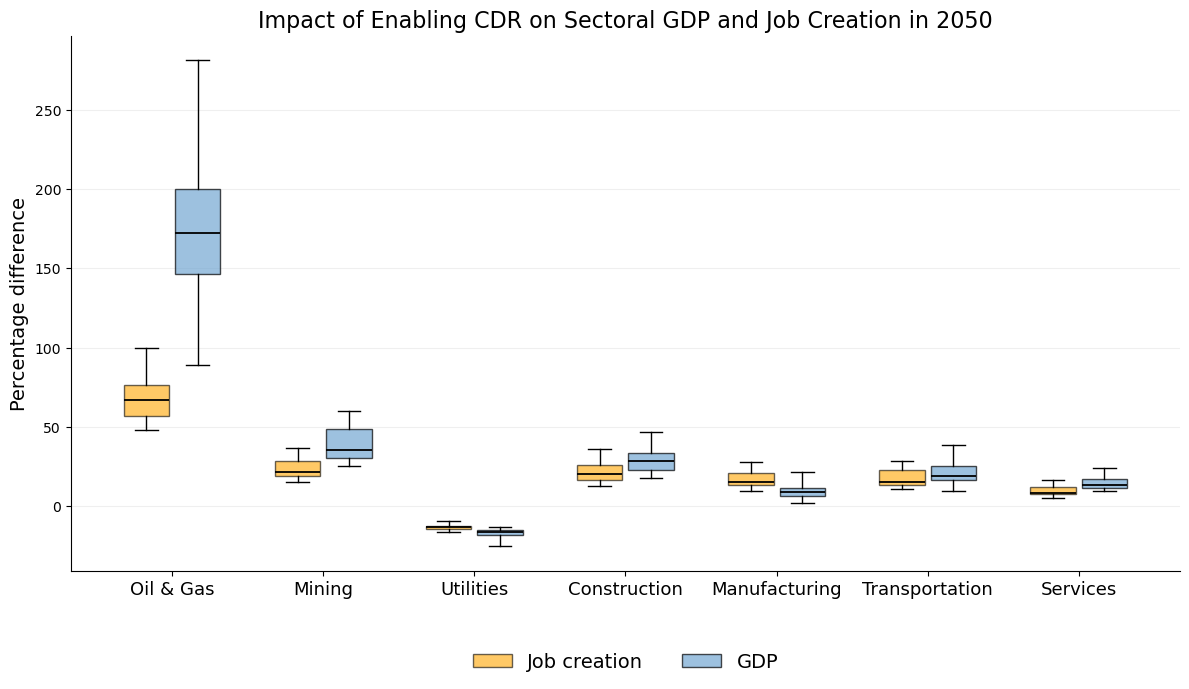

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ========== SETTINGS ==========
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

sectors = [
    #"Agriculture & Forestry",
    "Oil & Gas",
    "Mining",
    "Utilities",
    "Construction",
    "Manufacturing",
    "Transportation",
    "Services",
]
base_years_full = [2030, 2035, 2040, 2045, 2050]
idx_2050 = base_years_full.index(2050)
n_sectors = len(sectors)
block_size = len(base_years_full)  # 5

# ========== DATA (Job Creation; your first block) ==========
job_mins = [
    #-0.066088542, -3.061791056, 0.041260402, -0.645245046, 2.39612241,
    -0.433527786, -0.288538956, 5.134964267, 14.8380372, 48.17374472,
    -0.021559519, -0.436485067, 1.270447707, 6.549817648, 14.97660804,
    -0.017153031, -0.484346258, -1.459977084, -4.487060215, -16.33665718,
    -0.048790657, -1.12158647, 2.430082048, 6.438569929, 12.80435233,
    -0.438708647, -2.10286713, 0.620511312, 3.393362334, 9.284229695,
    -0.012907998, -0.124136062, 1.351908598, 4.523859803, 10.64510235,
    -0.006000457, -0.698372116, 0.394876463, 1.723833505, 5.315114987
]
job_q1 = [
    #-0.003104072, 0.002139921, 0.53043298, 0.582141833, 3.411807315,
    -0.009126395, 0.047581825, 8.040711093, 23.38717315, 56.64460047,
    -0.001588486, 0.019714436, 2.510619215, 11.13702524, 18.8144221,
    -0.002721637, -0.189079252, -0.731670832, -3.312499992, -14.2069237,
    -0.007435262, 0.020958468, 3.739154754, 8.649438997, 16.66854875,
    -0.003807372, 0.054541873, 2.336674601, 6.47615978, 13.48745609,
    -0.001661925, 0.028731612, 2.601016927, 6.600461818, 12.97119519,
    -0.000391333, 0.007232114, 0.931732231, 2.966900611, 7.289539718
]
job_med = [
    #-0.000155278, 0.069488927, 0.739176131, 1.266981622, 4.83145187,
    -0.0003214, 1.171340874, 10.5395483, 27.99011382, 66.9301238,
    1.78538e-05, 0.304129342, 3.693881871, 13.81544286, 21.59380338,
    0.000187332, -0.11002544, -0.544167754, -2.754437777, -13.42980867,
    0.000246316, 0.485490119, 5.380801314, 10.59584811, 20.47449422,
    0.00147144, 0.328168068, 3.148650423, 8.733947431, 15.45032732,
    0.000171699, 0.325473459, 3.832561428, 8.420243238, 15.25992283,
    0.000150496, 0.101989207, 1.368571659, 3.952753551, 8.261419841
]
job_q3 = [
    #0.002713314, 0.220654034, 1.054352037, 2.324592549, 6.904576258,
    0.007300779, 2.13267684, 14.90947845, 33.66840561, 76.44901299,
    0.002393957, 1.065536436, 5.092584496, 18.01790953, 28.40357946,
    0.001704201, -0.001990734, -0.22817249, -2.195303505, -12.47754142,
    0.005765841, 1.227093259, 6.807533079, 12.45059689, 25.70362566,
    0.005205697, 0.815836271, 4.199786396, 12.9814805, 20.56430168,
    0.002709612, 0.818021259, 4.66415293, 11.86003013, 22.48340781,
    0.00072727, 0.254750964, 1.832448567, 5.568653234, 12.222525
]
job_max = [
    #0.063971734, 0.525158252, 1.867695933, 4.197588387, 9.650925775,
    0.181825279, 5.106932246, 23.13130891, 48.07535175, 99.83155024,
    0.026301762, 1.65477475, 8.906639519, 24.96587179, 36.79796933,
    0.05902265, 1.357776573, 0.221296981, -1.015393432, -9.248178112,
    0.090651594, 7.443328025, 11.32626721, 17.39274925, 36.1057461,
    0.451856686, 1.519158927, 7.297128981, 17.68916575, 27.86178209,
    0.020570426, 1.901119839, 8.149532146, 14.8961473, 28.62770785,
    0.0084851, 0.614508499, 3.545882357, 7.91704795, 16.25746827
]

# ========== DATA (GDP; your second block) ==========
gdp_mins = [
    #-0.070154787, -2.260031773, -9.577584152, -23.59516611, -53.28451713,
    -0.117723137, -0.968162984, 3.642571542, 23.87281749, 89.04864686,
    -0.052307671, -6.770249149, 0.616718419, 10.95154896, 24.96868821,
    -0.172031439, -8.165442339, -4.107200646, -13.6732831, -25.37146843,
    -0.062358146, -0.81891347, 3.102441337, 8.268033947, 17.56827895,
    -0.12211176, -2.657654438, 0.071847813, -4.094810778, 2.094415029,
    -0.072375637, -1.503895042, 0.764933365, 0.623674292, 9.758880166,
    -0.030424977, -1.030128956, 0.562158995, 2.585415889, 9.209606268
]
gdp_q1 = [
    #-0.018876025, -0.226294733, -6.761724744, -18.78980639, -49.74716335,
    -0.006289945, 0.000936363, 7.399923971, 39.29123036, 146.3146592,
    -0.011041358, 0.00695453, 1.84859277, 17.55477062, 30.63648972,
    -0.007003353, -0.015456103, -2.432849885, -6.247083662, -18.3038674,
    -0.01511054, 0.02970538, 4.771478056, 11.3238162, 22.94289918,
    -0.015351329, 0.00276903, 2.092183473, -1.149396338, 6.259919985,
    -0.009474972, -0.024731786, 1.993107853, 5.07063769, 16.45810711,
    -0.002572174, 0.000355342, 1.136694712, 4.529693848, 11.63127785
]
gdp_med = [
    #-0.003755076, -0.053482665, -4.9481605, -15.09770638, -46.54021726,
    -2.31588E-05, 0.354179518, 10.39999254, 58.27247941, 172.1655017,
    0.001567476, 0.203726335, 3.39742999, 22.02111713, 35.45079569,
    0.001211476, 0.09640234, -0.449009471, -4.91780241, -16.51001485,
    -0.000585947, 0.488912057, 6.659466347, 13.77133199, 28.27190498,
    5.21687E-05, 0.103762204, 2.86164705, 0.495717376, 8.710947999,
    0.000141112, 0.08952878, 3.250210563, 6.847794396, 18.76078324,
    0.000132209, 0.068156787, 1.685242739, 5.755453273, 13.01584928
]
gdp_q3 = [
    #0.005695811, 0.007406147, -4.396736323, -13.27070514, -43.48628655,
    0.009210093, 0.808071306, 15.66280183, 86.08157195, 199.8028256,
    0.012023544, 0.855344829, 5.349740485, 29.46861595, 48.42895721,
    0.009215172, 0.408727995, 0.084720191, -3.231563211, -14.97938907,
    0.005910895, 1.149100009, 8.119323863, 16.32545967, 33.51741193,
    0.004943652, 0.630991564, 3.582494536, 2.375767881, 11.68551866,
    0.006221951, 0.452323534, 3.890714102, 10.30880265, 25.57978373,
    0.00134334, 0.193847659, 2.111688539, 7.530520873, 17.29630909
]
gdp_max = [
    #0.106122549, 1.230666605, -2.136753391, -10.13745734, -39.35490348,
    0.099695181, 3.122870731, 27.32064759, 115.9673848, 281.4057829,
    0.224552666, 2.442933584, 11.12172364, 40.97873691, 60.044713,
    0.050575993, 18.42432275, 1.839340808, -1.790201999, -13.44330602,
    0.129676172, 6.631047057, 13.8004678, 22.07731014, 46.80318272,
    0.119328785, 1.342361429, 6.566725893, 5.276886532, 21.30416404,
    0.084922684, 2.181022419, 6.481463761, 17.07043636, 38.52566117,
    0.037284151, 0.78942682, 4.464600478, 10.63512911, 23.82168607
]

# ========== Helper to extract 2050 stats by sector ==========
def stats_for_year(mins, q1, med, q3, max_, idx_2050, block=5):
    out = []
    for si in range(n_sectors):
        k = si * block + idx_2050
        out.append({
            "whislo": mins[k],
            "q1":     q1[k],
            "med":    med[k],
            "q3":     q3[k],
            "whishi": max_[k],
        })
    return out

job_stats_2050 = stats_for_year(job_mins, job_q1, job_med, job_q3, job_max, idx_2050, block_size)
gdp_stats_2050 = stats_for_year(gdp_mins, gdp_q1, gdp_med, gdp_q3, gdp_max, idx_2050, block_size)

# ---- Positions: make the two boxes per sector touch ----
pair_gap = 1.0    # spacing between sector groups (adjust if you want tighter/wider groups)
offset   = 0.17    # half-distance inside the pair; with width=0.6, boxes exactly touch at the center
width    = 0.3

positions_job = []
positions_gdp = []
centers = []

for si in range(n_sectors):
    center = si * pair_gap + 1
    positions_job.append(center - offset)   # left box (Job)
    positions_gdp.append(center + offset)   # right box (GDP)
    centers.append(center)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 7))

# Job Creation (salmon)
ax.bxp(
    job_stats_2050,
    positions=positions_job,
    widths=width,
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "orange", "alpha": 0.6, "edgecolor": "black"},
    medianprops={"color": "black", "linewidth": 1.3},
    whiskerprops={"color": "black"},
    capprops={"color": "black"},
)

# GDP (light blue)
ax.bxp(
    gdp_stats_2050,
    positions=positions_gdp,
    widths=width,
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#74a7d2", "alpha": 0.7, "edgecolor": "black"},
    medianprops={"color": "black", "linewidth": 1.3},
    whiskerprops={"color": "black"},
    capprops={"color": "black"},
)

# Axes, labels, legend
ax.set_xticks(centers)
ax.set_xticklabels(sectors, rotation=0, fontsize=13)
ax.set_ylabel("Percentage difference", fontsize=14)
ax.set_title("Impact of Enabling CDR on Sectoral GDP and Job Creation in 2050", fontsize=16)
ax.grid(axis="y", alpha=0.2)

legend_handles = [
    Patch(facecolor="orange",    edgecolor="black", alpha=0.6, label="Job creation"),
    Patch(facecolor="#74a7d2", edgecolor="black", alpha=0.7, label="GDP"),
]

ax.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.12), fontsize=14)

plt.tight_layout()
plt.show()

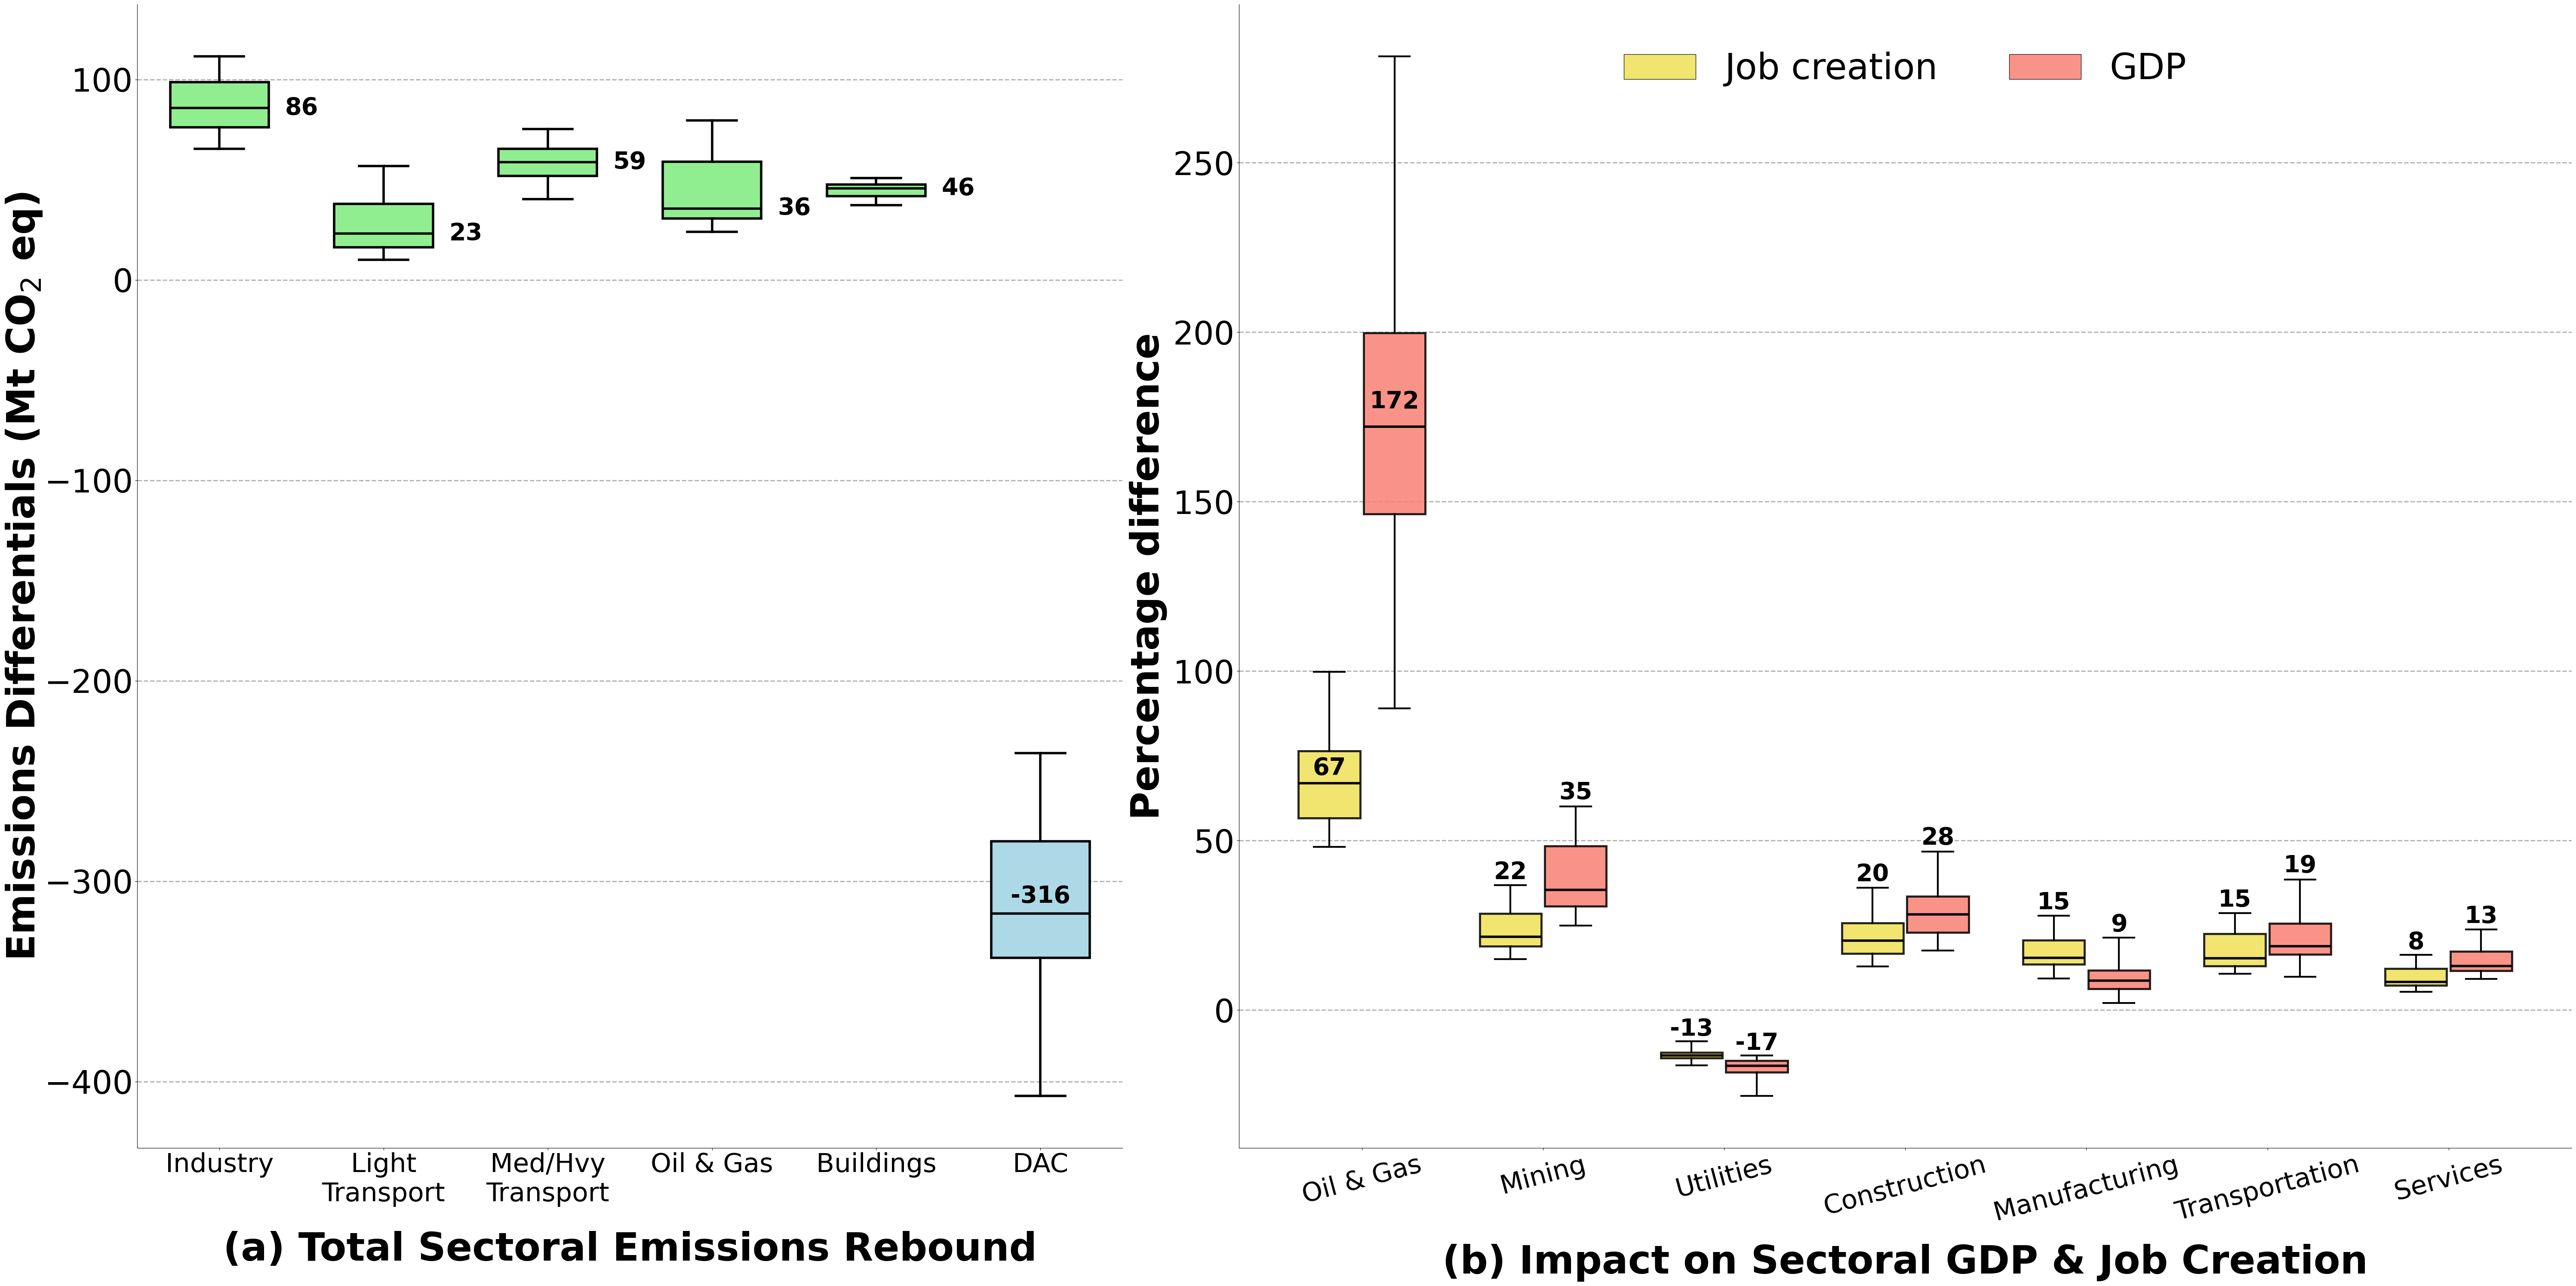

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import textwrap

# Read data from Excel file
df = pd.read_excel("2050 Emissions Deltas - Navius rev01.xlsx")

# Data for bar chart
sectors = ["Fugitive Sources", "Energy Production", "Electricity", "Transport", "Industry - Process", "DAC"]
emissions_differentials = [2, 4, 5, 1, 1, -13]
colors_bar = ['lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightblue']

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(60, 30),
                         gridspec_kw={'width_ratios': [0.85, 1.15]})
ax1, ax2 = axes


# Customize boxplot colors
boxprops = dict(linewidth=4, color='black')
medianprops = dict(linewidth=4, color='black')
whiskerprops = dict(linewidth=4, color='black')
capprops = dict(linewidth=4, color='black')

# Create boxplot with customized properties
bp = ax1.boxplot(df.values, labels=df.columns, boxprops=boxprops, medianprops=medianprops,
                whiskerprops=whiskerprops, capprops=capprops, patch_artist=True, widths=0.6)  # Reduced box width

# Set specific colors for each box
colors = ['lightblue'] * len(df.columns)
colors[0] = 'lightgreen'
colors[1] = 'lightgreen'
colors[2] = 'lightgreen'
colors[3] = 'lightgreen'
colors[4] = 'lightgreen'

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Function to wrap text for tick labels (ensuring it only breaks at spaces)
def wrap_labels(labels, width):
    return ['\n'.join(textwrap.wrap(label, width, break_long_words=False)) for label in labels]

# Wrap x-axis labels with improved spacing
wrapped_labels = wrap_labels(df.columns, 10)

# Add labels for max, min, median
for i, col in enumerate(df.columns):
    #ax1.text(i + 1, df[col].max() + 0.03 * (df[col].max() - df[col].min()), f'{df[col].max():.0f}', ha='center', va='bottom', color='black', fontsize=40, fontweight='bold')
    #ax1.text(i + 1, df[col].min() - 0.06 * (df[col].max() - df[col].min()), f'{df[col].min():.0f}', ha='center', va='top', color='black', fontsize=40, fontweight='bold')
    if i in [0, 1, 2, 3, 4]:
        ax1.text(i + 1.5, df[col].median(), f'{df[col].median():.0f}', ha='center', va='center', color='black', fontsize=40, fontweight='bold')  # Moved inside box
    else:
        ax1.text(i + 1, df[col].median() + 0.05 * (df[col].max() - df[col].min()), f'{df[col].median():.0f}', ha='center', va='center', color='black', fontsize=40, fontweight='bold') # Moved inside box

# Axis labels and formatting for boxplot
ax1.set_xlabel('(a) Total Sectoral Emissions Rebound', fontsize=65, fontweight='bold', labelpad=40)
ax1.set_ylabel('Emissions Differentials (Mt CO$_2$ eq)', fontsize=65, fontweight='bold', labelpad=1)
ax1.set_xticks(range(1, len(df.columns) + 1))
ax1.set_xticklabels(wrapped_labels, rotation=0, fontsize=44)
ax1.tick_params(axis='y', labelsize=54)
ax1.grid(True, axis = 'y', linestyle='--', linewidth=2)

# ------------------- RIGHT SUBPLOT (b) GDP & Jobs boxplot ------------------- #
# Instead of creating a new fig/ax, use ax2 here:

# Settings
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

sectors = ["Oil & Gas","Mining","Utilities","Construction","Manufacturing","Transportation","Services"]
base_years_full = [2030, 2035, 2040, 2045, 2050]
idx_2050 = base_years_full.index(2050)
n_sectors = len(sectors)
block_size = len(base_years_full)

# (define job_mins, job_q1, ... gdp_max exactly as in your first script)

def stats_for_year(mins, q1, med, q3, max_, idx_2050, block=5):
    out = []
    for si in range(n_sectors):
        k = si * block + idx_2050
        out.append({
            "whislo": mins[k],
            "q1":     q1[k],
            "med":    med[k],
            "q3":     q3[k],
            "whishi": max_[k],
        })
    return out

job_stats_2050 = stats_for_year(job_mins, job_q1, job_med, job_q3, job_max, idx_2050, block_size)
gdp_stats_2050 = stats_for_year(gdp_mins, gdp_q1, gdp_med, gdp_q3, gdp_max, idx_2050, block_size)

pair_gap = 1.0
offset   = 0.18
width    = 2*offset - 0.02

positions_job = []
positions_gdp = []
centers = []
for si in range(n_sectors):
    center = si * pair_gap + 1
    positions_job.append(center - offset)
    positions_gdp.append(center + offset)
    centers.append(center)

# ---- Plot jobs & GDP into ax2 ----
ax2.bxp(
    job_stats_2050, positions=positions_job, widths=width, showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#EFE056", "alpha": 0.85, "edgecolor": "black", "linewidth": 3.5},
    medianprops={"color": "black", "linewidth": 4},
    whiskerprops={"color": "black", "linewidth": 3},
    capprops={"color": "black", "linewidth": 3},
)

ax2.bxp(
    gdp_stats_2050, positions=positions_gdp, widths=width, showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "salmon", "alpha": 0.85, "edgecolor": "black", "linewidth": 3.5},
    medianprops={"color": "black", "linewidth": 4},
    whiskerprops={"color": "black", "linewidth": 3},
    capprops={"color": "black", "linewidth": 3},
)


ax2.set_xticks(centers)
ax2.set_xticklabels(sectors, rotation=15, fontsize=44)
ax2.set_ylabel("Percentage difference", fontsize=65, fontweight='bold', labelpad=10)
ax2.set_xlabel("(b) Impact on Sectoral GDP & Job Creation", fontsize=65, fontweight='bold', labelpad=30)
ax2.grid(True, axis='y', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelsize=54)

# Jobs (orange boxes)
for i, (pos, stats) in enumerate(zip(positions_job, job_stats_2050)):
    if i == 0:
        yval = stats["med"]
    else:
        yval = stats["whishi"]
    ax2.text(pos, yval + 0.02*(stats["whishi"] - stats["whislo"]),  # add 2% of box height
             f'{stats["med"]:.0f}', ha='center', va='bottom',
             fontsize=40, fontweight='bold', color='black')

# GDP (salmon boxes)
for i, (pos, stats) in enumerate(zip(positions_gdp, gdp_stats_2050)):
    if i == 0:
        yval = stats["med"]
    else:
        yval = stats["whishi"]
    ax2.text(pos, yval + 0.02*(stats["whishi"] - stats["whislo"]),  # add 2% of whisker span
             f'{stats["med"]:.0f}', ha='center', va='bottom',
             fontsize=40, fontweight='bold', color='black')



from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#EFE056",  edgecolor="black", alpha=0.85, label="Job creation"),
    Patch(facecolor="salmon", edgecolor="black", alpha=0.85, label="GDP"),
]

ax2.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.9),  # anchor above the axis
           ncol=2, frameon=False, fontsize=60)


plt.subplots_adjust(left=0.05, right=0.98, top=0.92, bottom=0.22, wspace=0.25)


for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ------------------- Final layout ------------------- #
plt.tight_layout()
plt.show()